In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from fontTools.merge import cmap
from matplotlib.pyplot import subplot

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer

from dfmodel import DigitalFamilyBinary

In [2]:
design_matrix_test = pd.read_csv(
    "../0_clinical_data/design_matrix_test.tsv",
    sep='\t'
)

In [3]:
design_matrix = pd.read_csv(
    "../0_clinical_data/design_matrix_train.tsv",
    sep='\t'
)

In [4]:
clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "mental_status_ambulance",
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "crp_day1",
    "trc_emergency_department",
    "sex",
    "age",
]

continuous_clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "trc_emergency_department",
    "crp_day1",
    "age",
    #"mental_status_ambulance",
]

categorical_clinical_columns = [
    "mental_status_ambulance",
]

In [5]:
design_matrix['survival_30_day'] = np.where(design_matrix['survival_days'] <= 30, 1, 0)
design_matrix_test['survival_30_day'] = np.where(design_matrix_test['survival_days'] <= 30, 1, 0)


design_matrix['future_deterioration'] = np.where(
    (design_matrix['sofa_score_increase_day2'] > 1) & (design_matrix['sofa_score_increase_day3'] > 1), 1, 0
)

design_matrix_test['future_deterioration'] = np.where(
    (design_matrix_test['sofa_score_increase_day2'] > 1) & (design_matrix_test['sofa_score_increase_day3'] > 1), 1, 0
)

In [6]:
training_data = design_matrix.copy()
testing_data = design_matrix_test.copy()

clinical_scaler = StandardScaler()

clinical_imputer = SimpleImputer()
min_max_scaler = MinMaxScaler()
sex_scaler = MinMaxScaler((0, 1))
constant_imputer = SimpleImputer(strategy="constant", fill_value=1.0)

training_data[continuous_clinical_columns] = clinical_imputer.fit_transform(training_data[continuous_clinical_columns])
training_data[["mental_status_ambulance"]] = constant_imputer.fit_transform(training_data[["mental_status_ambulance"]])

training_data[continuous_clinical_columns] = clinical_scaler.fit_transform(training_data[continuous_clinical_columns])
training_data[['sex']] = sex_scaler.fit_transform(training_data[['sex']])
#training_data[clinical_columns] = min_max_scaler.fit_transform(training_data[clinical_columns])

testing_data[continuous_clinical_columns] = clinical_imputer.transform(testing_data[continuous_clinical_columns])
testing_data[["mental_status_ambulance"]] = constant_imputer.transform(testing_data[["mental_status_ambulance"]])

testing_data[continuous_clinical_columns] = clinical_scaler.transform(testing_data[continuous_clinical_columns])
testing_data[['sex']] = sex_scaler.transform(testing_data[['sex']])
#testing_data[clinical_columns] = min_max_scaler.transform(testing_data[clinical_columns])


In [7]:
training_data[clinical_columns]

,sao2_ambulance,resp_frequency_ambulance,heart_rate_ambulance,syst_bp_ambulance,map_ambulance,mental_status_ambulance,temperature_ambulance,crea_emergency_department,bili_emergency_department,crp_day1,trc_emergency_department,sex,age
0,-0.440508,-0.862829,0.347360,-0.182072,0.270374,1.0,0.694719,-0.555306,-2.677143e-16,-0.345625,-0.906163,1.0,-2.365415
1,-1.577464,-0.128251,0.216787,0.322727,1.041185,1.0,-1.451047,-0.037510,-2.677143e-16,-0.434355,1.385753,0.0,-0.075467
2,0.582753,2.075484,0.564982,-0.182072,0.000000,1.0,1.084859,-0.630818,-2.677143e-16,0.679707,0.384794,1.0,-0.155328
3,-1.008986,0.483898,-0.784273,-0.434471,-0.992900,1.0,-0.183094,-0.026722,-2.677143e-16,1.665603,-0.859389,0.0,1.115809
4,-0.213116,-1.597408,-1.611235,0.394841,1.940465,1.0,-3.109139,-0.188534,-8.225653e-01,-0.953922,0.160279,0.0,-2.188787
...,...,...,...,...,...,...,...,...,...,...,...,...,...
675,0.810144,1.096046,-0.740748,-0.542642,-0.714552,1.0,-1.255977,-0.350345,-2.677143e-16,-0.158304,3.874118,1.0,0.295378
676,0.127971,-0.128251,-0.436078,0.539069,0.998362,1.0,0.207045,-0.673968,3.077577e-01,-0.808996,0.712210,0.0,0.009216
677,-1.691159,1.096046,-0.523127,0.286670,0.420254,1.0,-1.353512,-0.576881,-2.197263e-01,-0.345625,1.900264,1.0,0.058323
678,0.469057,0.606327,-0.523127,-0.722927,0.000000,2.0,0.304580,-0.663181,-5.965007e-01,-0.207599,0.188344,0.0,0.413090


In [8]:
df_estimator = DigitalFamilyBinary(n_neighbors=10, neighbor_metric="euclidean")

In [9]:
df_estimator.fit(training_data, features=clinical_columns)

In [10]:
training_data['Sepsis Rates'] = df_estimator.predict(training_data, features=clinical_columns, target_column="sepsis_or_septic_shock", bootstrap=False)
training_data['Infection Rates'] = df_estimator.predict(training_data, features=clinical_columns, target_column="verified_infection", bootstrap=False)
training_data['Future Organ Dysfunction'] = df_estimator.predict(training_data, features=clinical_columns, target_column="future_deterioration", bootstrap=False)
training_data['30 Day Mortality'] = df_estimator.predict(training_data, features=clinical_columns, target_column="survival_30_day", bootstrap=False)
training_data['ICU'] = df_estimator.predict(training_data, features=clinical_columns, target_column="critical_care", bootstrap=False)

In [11]:
from fa2_modified import ForceAtlas2
import matplotlib.pyplot as plt
import networkx as nx

G = df_estimator.network_


In [12]:
positions = nx.forceatlas2_layout(
    G,
    max_iter=1000,
    seed=0,
    #strong_gravity=True,
    dissuade_hubs=True
)

In [13]:
display_columns = [
    "Sepsis Rates",
    "Infection Rates",
    "Future Organ Dysfunction",
    "30 Day Mortality",
    "ICU",
]

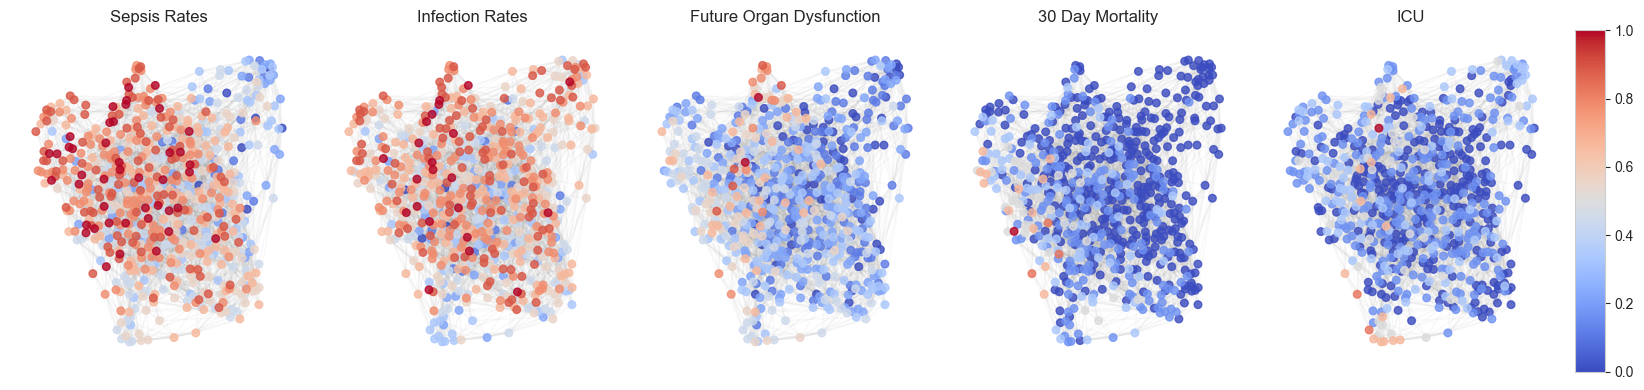

In [14]:
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt

fig, axs = plt.subplots(
    nrows=1,
    ncols=6,
    gridspec_kw={'width_ratios': [1, 1, 1, 1, 1, 0.1]}
)

for i, col in enumerate(display_columns):

    # values = training_data[col].to_numpy()
    # cmap = plt.cm.coolwarm
    # norm = plt.Normalize(vmin=training_data[col].min(), vmax=training_data[col].max())
    # colors = cmap(norm(values))

    color_normalizer = MinMaxScaler((0, 1))

    values = MinMaxScaler().fit_transform(training_data[[col]])

    color_map = dict(zip(training_data.index, values))
    ordered_nodes = list(training_data.sort_values(col, ascending=True).index)

    node_colors = [color_map[node] for node in ordered_nodes]

    nx.draw_networkx_nodes(G, positions, node_size=30, node_color=node_colors, nodelist=ordered_nodes, cmap="coolwarm", alpha=0.8, ax=axs[i])
    nx.draw_networkx_edges(G, positions, edge_color="gray", alpha=0.05, ax=axs[i])

    axs[i].axis("off")

    axs[i].set_title(col)



sm = plt.cm.ScalarMappable(cmap="coolwarm")
cbar = fig.colorbar(sm, cax=axs[-1], orientation="vertical")


fig.set_size_inches((8.27 * 2, 4))
plt.tight_layout()

In [15]:
sm

In [16]:
fig.savefig(
    "diagnosis_prognosis_maps.pdf", dpi=300, bbox_inches="tight"
)

In [17]:
training_data.sort_values('30 Day Mortality', ascending=False)

,injection,sao2_ambulance,resp_frequency_ambulance,heart_rate_ambulance,syst_bp_ambulance,map_ambulance,mental_status_ambulance,temperature_ambulance,crea_emergency_department,bili_emergency_department,...,abdominal_infection,skin_and_soft_tissue_infection,pneumonia,survival_30_day,future_deterioration,Sepsis Rates,Infection Rates,Future Organ Dysfunction,30 Day Mortality,ICU
130,SA_BOX_6-2233_S2-E8_1_5870,-2.487029,1.096046,0.739079,-1.083497,-1.678066,1.0,-1.743651,1.008871,-2.677143e-16,...,0.0,0.0,1.0,1,0,0.8,0.7,0.5,0.6,0.2
475,SA_BOX_13-377_S1-G1_1_6502,-4.419854,2.320344,0.347360,-0.722927,-0.179266,1.0,-0.768303,0.577374,-2.677143e-16,...,0.0,0.0,0.0,0,1,0.9,0.7,0.7,0.5,0.4
535,SA_BOX_13-2283_S1-G5_1_6534,-3.282898,2.075484,-0.044359,-1.804637,-2.919928,4.0,1.377463,1.181470,-8.225653e-01,...,0.0,0.0,0.0,0,1,1.0,0.9,0.5,0.5,0.2
73,SA_BOX_13-2658_S1-A2_1_6504,-1.918551,0.606327,0.129738,0.178498,0.000000,1.0,-0.183094,-0.199321,-2.677143e-16,...,0.0,0.0,0.0,1,0,1.0,0.8,0.2,0.5,0.0
462,SA_BOX_11-818_S4-B11_1_6382,-0.326812,-0.617970,0.347360,-1.263782,0.000000,1.0,-0.670768,-0.059085,-2.677143e-16,...,0.0,1.0,0.0,0,0,0.8,0.8,0.5,0.4,0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,SA_BOX_6-2365_S2-H6_1_5856,-0.554203,0.116608,1.043750,1.512608,2.261636,1.0,0.109510,-0.630818,-6.718555e-01,...,0.0,0.0,1.0,0,1,0.4,0.9,0.1,0.0,0.0
152,SA_BOX_7-26_S4-H4_1_5938,-0.099421,-0.250681,0.129738,-1.083497,0.000000,2.0,1.572533,-0.436645,-2.197263e-01,...,0.0,0.0,0.0,0,0,0.8,0.8,0.4,0.0,0.1
380,SA_BOX_12-2462_S5-B11_1_6480,-0.326812,-0.128251,-1.393613,-0.542642,0.000000,1.0,0.889789,-0.253258,-2.197263e-01,...,0.0,0.0,0.0,0,1,0.8,0.7,0.2,0.0,0.0
378,SA_BOX_1-2438_S1-D3_1_6808,1.037535,-1.230119,1.391944,-0.939269,-0.778786,1.0,0.402115,-0.317983,-3.704361e-01,...,0.0,0.0,0.0,0,0,0.3,0.2,0.2,0.0,0.1


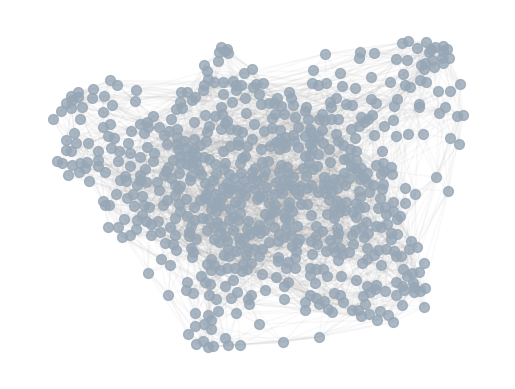

In [18]:


nx.draw_networkx_nodes(G, positions, node_size=50, node_color="#97A7B6", alpha=0.8)
nx.draw_networkx_edges(G, positions, edge_color="gray", alpha=0.05)
plt.axis('off')
plt.savefig(
    "overall_map.pdf", dpi=300, bbox_inches="tight"
)
plt.show()

In [19]:
training_data['mortality_30_day'] = np.where(training_data['survival_days'] <= 30, 1, 0)

In [20]:
training_data['mortality_30_day'].value_counts()

mortality_30_day
0    611
1     69
Name: count, dtype: int64

In [21]:

color_map = dict(zip(training_data.index, training_data['critical_care']))

node_colors = [color_map[node] for node in G.nodes()]


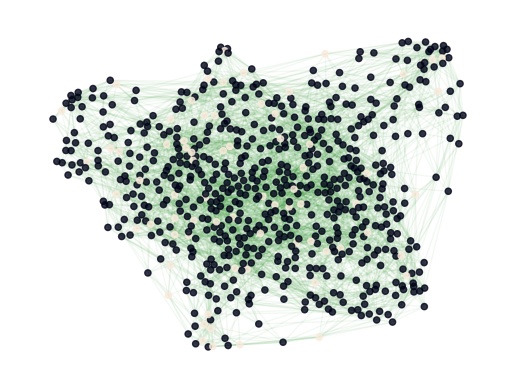

In [22]:
nx.draw_networkx_nodes(G, positions, node_size=20, node_color=node_colors, alpha=0.8,)
nx.draw_networkx_edges(G, positions, edge_color="green", alpha=0.05)
plt.axis('off')
plt.show()